# RQ1 Diagnostics: Metrics, Null Distribution, and Significance

This notebook visualises the outputs of one RQ1 benchmark run.

What you get below:

1. A summary of the run (config, null state, observed metrics, null draws).
2. Per-layer observed values for each metric (CKA, PWCCA, k-NN overlap), with a null mean and 95% range overlay where the null is available.
3. p-value, adjusted p-value, and z-score vs layer for metrics that have a null distribution.
4. Per-layer null distribution histograms, with the observed value marked.
5. Optional diagnostics: scene-type enrichment in the high-null tail.

Set `RUN_ID` in the setup cell to point at the run you want to inspect.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----
RUN_ID = "rq1_smoke_hypersim-20260524-200110"
NULL_FILENAME = "null_distribution.csv"
NULL_STATE_FILENAME = "null_distribution_state.json"
ALPHA = 0.05  # significance threshold for p-value plots

# ---- Resolve project root ----
cwd = Path.cwd().resolve()
if (cwd / "README.md").exists():
    project_root = cwd
elif (cwd.parent / "README.md").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not find project root (README.md not found).")

run_dir = project_root / "results" / "runs" / RUN_ID
null_dir = project_root / "results" / "runs" / "null_distributions" / RUN_ID

metrics_path = run_dir / "metrics" / "metrics.csv"
null_path = null_dir / NULL_FILENAME
null_state_path = null_dir / NULL_STATE_FILENAME

# ---- Load ----
metrics = pd.read_csv(metrics_path)
null_df = pd.read_csv(null_path)
null_state = (
    json.loads(null_state_path.read_text(encoding="utf-8"))
    if null_state_path.exists()
    else {}
)


def _layer_idx(s):
    """Extract a numeric index from a layer name like 'layer_07'."""
    try:
        return int(str(s).split("_")[-1])
    except Exception:
        return 10**9


metrics["layer_idx"] = metrics["layer"].map(_layer_idx)
metrics = metrics.sort_values(["pair", "metric", "layer_idx"]).reset_index(drop=True)
null_df["layer_idx"] = null_df["layer"].map(_layer_idx)
null_df = null_df.sort_values(["pair", "metric", "layer_idx", "draw_id"]).reset_index(drop=True)

print(f"Run ID         : {RUN_ID}")
print(f"Metrics file   : {metrics_path}")
print(f"Null file      : {null_path}")
print(f"Null state     : {null_state}")
print()
print("Observed metric summary:")
display(
    metrics.groupby(["pair", "metric"])["value"]
    .agg(["count", "min", "mean", "max"])
    .round(4)
)
print("\nNull draws per layer/metric:")
display(
    null_df.groupby(["pair", "metric", "layer"])
    .size()
    .rename("n_draws")
    .reset_index()
)

Run ID         : rq1_smoke_hypersim-20260524-200110
Metrics file   : C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\rq1_smoke_hypersim-20260524-200110\metrics\metrics.csv
Null file      : C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\null_distributions\rq1_smoke_hypersim-20260524-200110\null_distribution.csv
Null state     : {'artifact_path': 'results/runs/null_distributions/rq1_smoke_hypersim-20260524-200110/null_distribution.csv', 'n_rows': 5400, 'stop_reason': 'max_draws_reached', 'batches_completed': 5}

Observed metric summary:


count     min    mean     max
pair          metric                                    
depth-normals cka             12  0.6059  0.7617  0.8205
              knn_overlap     12  0.5550  0.6196  0.6750
              pwcca           12  1.0000  1.0000  1.0000
rgb-depth     cka             12  0.2528  0.4937  0.8181
              knn_overlap     12  0.6200  0.6888  0.8200
              pwcca           12  1.0000  1.0000  1.0000
rgb-normals   cka             12  0.2039  0.3615  0.5567
              knn_overlap     12  0.6000  0.6325  0.6700
              pwcca           12  1.0000  1.0000  1.0000


Null draws per layer/metric:


,pair,metric,layer,n_draws
0,depth-normals,cka,layer_00,50
1,depth-normals,cka,layer_01,50
2,depth-normals,cka,layer_02,50
3,depth-normals,cka,layer_03,50
4,depth-normals,cka,layer_04,50
...,...,...,...,...
103,rgb-normals,pwcca,layer_07,50
104,rgb-normals,pwcca,layer_08,50
105,rgb-normals,pwcca,layer_09,50
106,rgb-normals,pwcca,layer_10,50


In [21]:
# Sanity check: no leakage between matched (observed) and null draws.
print("=== Null-distribution leakage check ===\n")

n_total = len(null_df)

# 1) Every null draw must be cross-scene (left != right scene).
if "is_cross_scene" in null_df.columns:
    n_same_scene = int((~null_df["is_cross_scene"]).sum())
    print(f"Same-scene draws   : {n_same_scene} / {n_total}  {'PASS' if n_same_scene == 0 else 'FAIL'}")
elif {"left_scene_id", "right_scene_id"}.issubset(null_df.columns):
    n_same_scene = int((null_df["left_scene_id"] == null_df["right_scene_id"]).sum())
    print(f"Same-scene draws   : {n_same_scene} / {n_total}  {'PASS' if n_same_scene == 0 else 'FAIL'}")
else:
    print("Same-scene check   : SKIP (columns missing)")

# 2) Every null draw should be cross-type (different scene types).
if "is_cross_type" in null_df.columns:
    n_same_type = int((~null_df["is_cross_type"]).sum())
    print(f"Same-type draws    : {n_same_type} / {n_total}  {'PASS' if n_same_type == 0 else 'FAIL'}")
elif {"left_scene_type", "right_scene_type"}.issubset(null_df.columns):
    n_same_type = int((null_df["left_scene_type"] == null_df["right_scene_type"]).sum())
    print(f"Same-type draws    : {n_same_type} / {n_total}  {'PASS' if n_same_type == 0 else 'FAIL'}")
else:
    print("Same-type check    : SKIP (columns missing)")

# 3) No null value should exceed the observed value for its hypothesis.
obs_lookup = metrics.set_index(["pair", "metric", "layer"])["value"].to_dict()
merged_check = null_df.copy()
merged_check["obs_value"] = merged_check.apply(
    lambda r: obs_lookup.get((r["pair"], r["metric"], r["layer"]), np.nan), axis=1
)
n_exceed = int((merged_check["null_value"] >= merged_check["obs_value"]).sum())
pct = 100 * n_exceed / n_total if n_total else 0
print(f"Null >= observed   : {n_exceed} / {n_total} ({pct:.2f}%)  (expect ~0 if signal is strong)")

# 4) Sample-size consistency: all draws for a hypothesis use the same n_samples.
if "n_samples" in null_df.columns:
    sizes = null_df.groupby(["pair", "metric", "layer"])["n_samples"].nunique()
    inconsistent = sizes[sizes > 1]
    if inconsistent.empty:
        print(f"n_samples consistent: PASS (all hypotheses use a single sample size)")
    else:
        print(f"n_samples consistent: FAIL ({len(inconsistent)} hypotheses have mixed sizes)")
        display(inconsistent)

print("\n=== End leakage check ===")

=== Null-distribution leakage check ===

Same-scene draws   : 0 / 36000  PASS
Same-type draws    : 0 / 36000  PASS
Null >= observed   : 0 / 36000 (0.00%)  (expect ~0 if signal is strong)
n_samples consistent: PASS (all hypotheses use a single sample size)

=== End leakage check ===


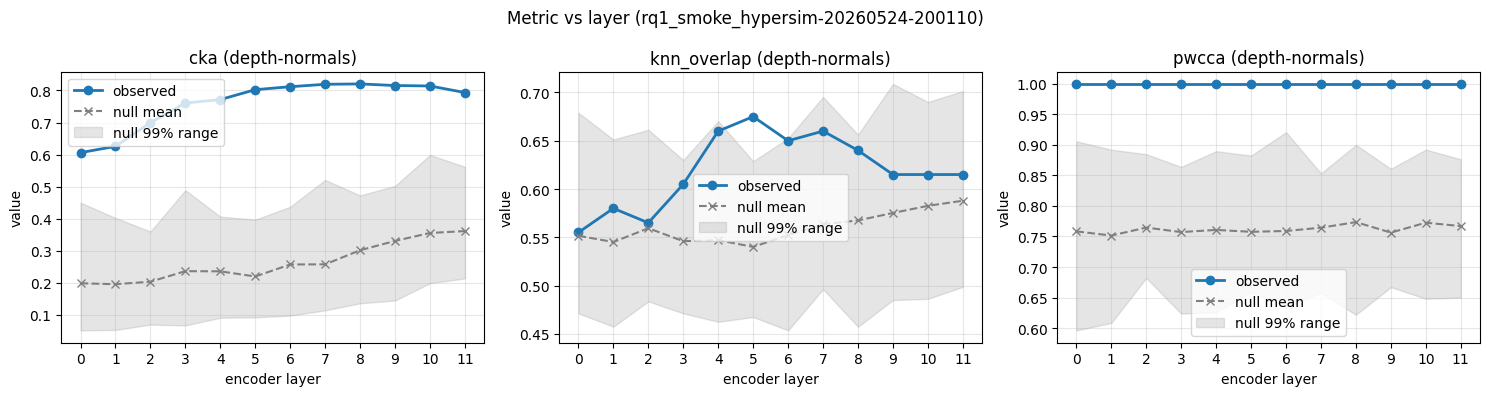

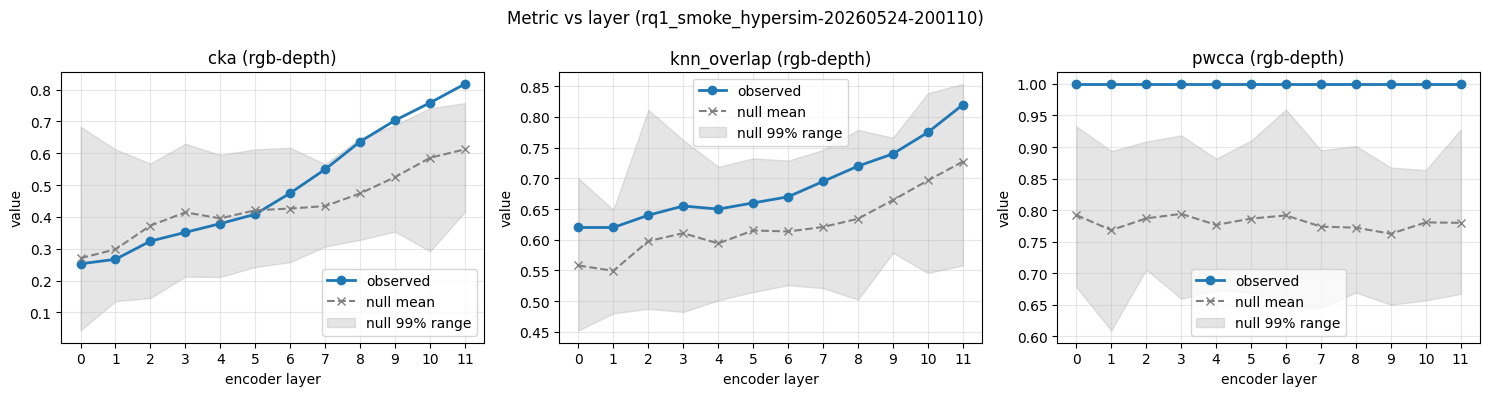

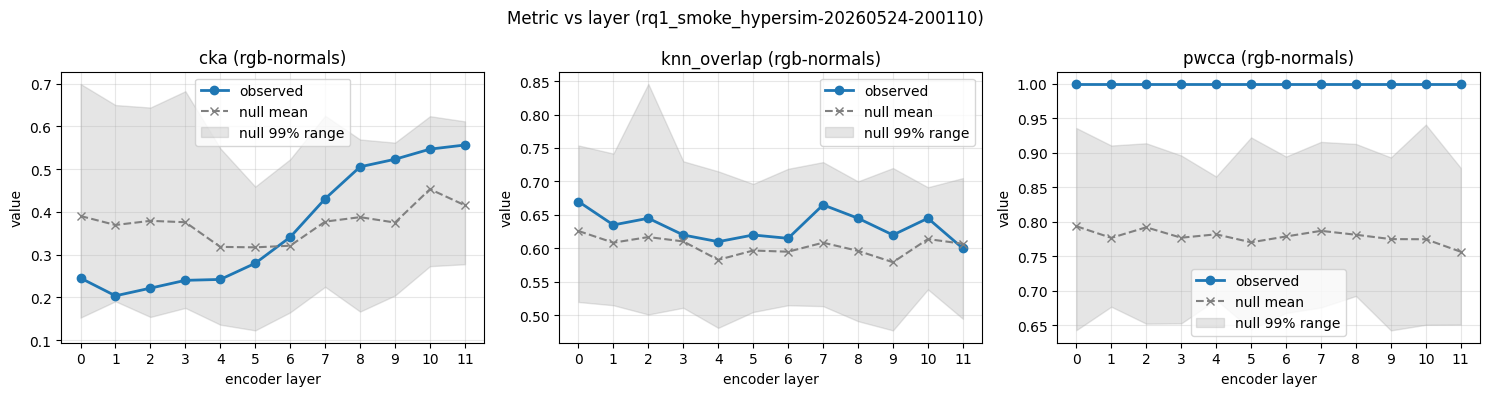

In [3]:
# Per-metric: observed value vs layer, with null mean and 95% range overlay where available.
metrics_with_null = set(null_df["metric"].unique())
metric_names = sorted(metrics["metric"].unique())
pairs = sorted(metrics["pair"].unique())

for pair in pairs:
    fig, axes = plt.subplots(1, len(metric_names), figsize=(5 * len(metric_names), 4))
    if len(metric_names) == 1:
        axes = [axes]

    for ax, m in zip(axes, metric_names):
        sub = metrics[(metrics["metric"] == m) & (metrics["pair"] == pair)].sort_values("layer_idx")
        if sub.empty:
            ax.set_title(f"{m} (no data)")
            ax.axis("off")
            continue

        layers = sub["layer_idx"].to_numpy()
        values = sub["value"].to_numpy()
        ax.plot(layers, values, marker="o", linewidth=2, label="observed")

        if m in metrics_with_null:
            null_sub = null_df[(null_df["metric"] == m) & (null_df["pair"] == pair)]
            if "null_mean" in sub.columns and sub["null_mean"].notna().any():
                ax.plot(layers, sub["null_mean"].to_numpy(), marker="x", linestyle="--", color="grey", label="null mean")
            if not null_sub.empty:
                bands = (
                    null_sub.groupby("layer_idx")["null_value"]
                    .agg(lo=lambda x: np.quantile(x, 0.005), hi=lambda x: np.quantile(x, 0.995))
                    .reset_index()
                    .sort_values("layer_idx")
                )
                ax.fill_between(bands["layer_idx"], bands["lo"], bands["hi"], color="grey", alpha=0.2, label="null 99% range")

        ax.set_title(f"{m} ({pair})")
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("value")
        ax.set_xticks(layers)
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Metric vs layer ({RUN_ID})")
    fig.tight_layout()
    plt.show()

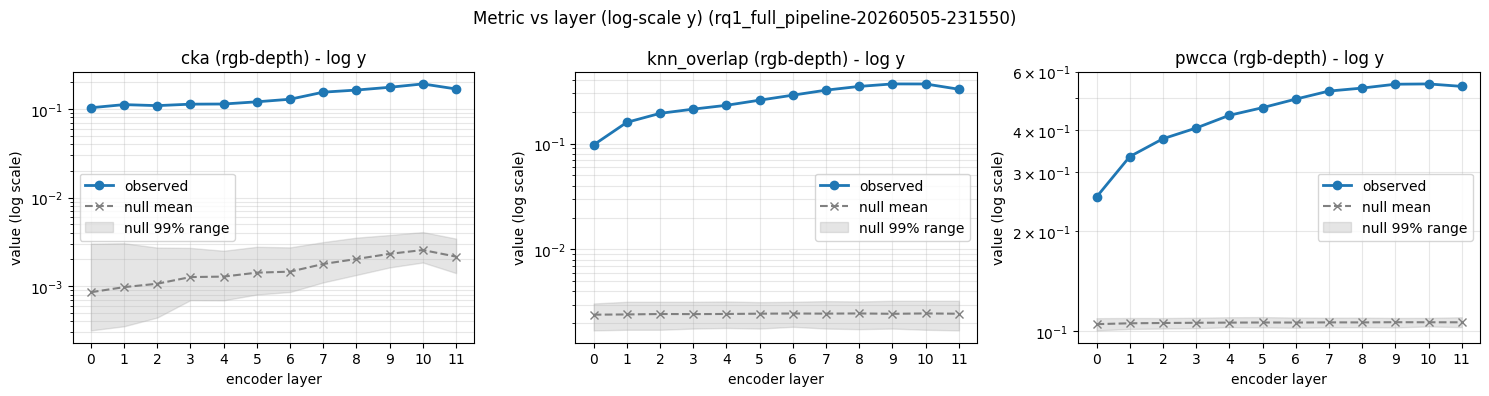

In [27]:
# Same plot as above, but with log-scale y-axis for readability near small null values.
EPS = 1e-12

for pair in pairs:
    fig, axes = plt.subplots(1, len(metric_names), figsize=(5 * len(metric_names), 4))
    if len(metric_names) == 1:
        axes = [axes]

    for ax, m in zip(axes, metric_names):
        sub = metrics[(metrics["metric"] == m) & (metrics["pair"] == pair)].sort_values("layer_idx")
        if sub.empty:
            ax.set_title(f"{m} (no data)")
            ax.axis("off")
            continue

        layers = sub["layer_idx"].to_numpy()
        values = np.maximum(sub["value"].to_numpy(dtype=float), EPS)
        ax.plot(layers, values, marker="o", linewidth=2, label="observed")

        if m in metrics_with_null:
            null_sub = null_df[(null_df["metric"] == m) & (null_df["pair"] == pair)]
            if "null_mean" in sub.columns and sub["null_mean"].notna().any():
                null_mean = np.maximum(sub["null_mean"].to_numpy(dtype=float), EPS)
                ax.plot(layers, null_mean, marker="x", linestyle="--", color="grey", label="null mean")

            if not null_sub.empty:
                bands = (
                    null_sub.groupby("layer_idx")["null_value"]
                    .agg(lo=lambda x: np.quantile(x, 0.005), hi=lambda x: np.quantile(x, 0.995))
                    .reset_index()
                    .sort_values("layer_idx")
                )
                lo = np.maximum(bands["lo"].to_numpy(dtype=float), EPS)
                hi = np.maximum(bands["hi"].to_numpy(dtype=float), EPS)
                ax.fill_between(bands["layer_idx"], lo, hi, color="grey", alpha=0.2, label="null 99% range")

        ax.set_yscale("log")
        ax.set_title(f"{m} ({pair}) - log y")
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("value (log scale)")
        ax.set_xticks(layers)
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3, which="both")

    fig.suptitle(f"Metric vs layer (log-scale y) ({RUN_ID})")
    fig.tight_layout()
    plt.show()

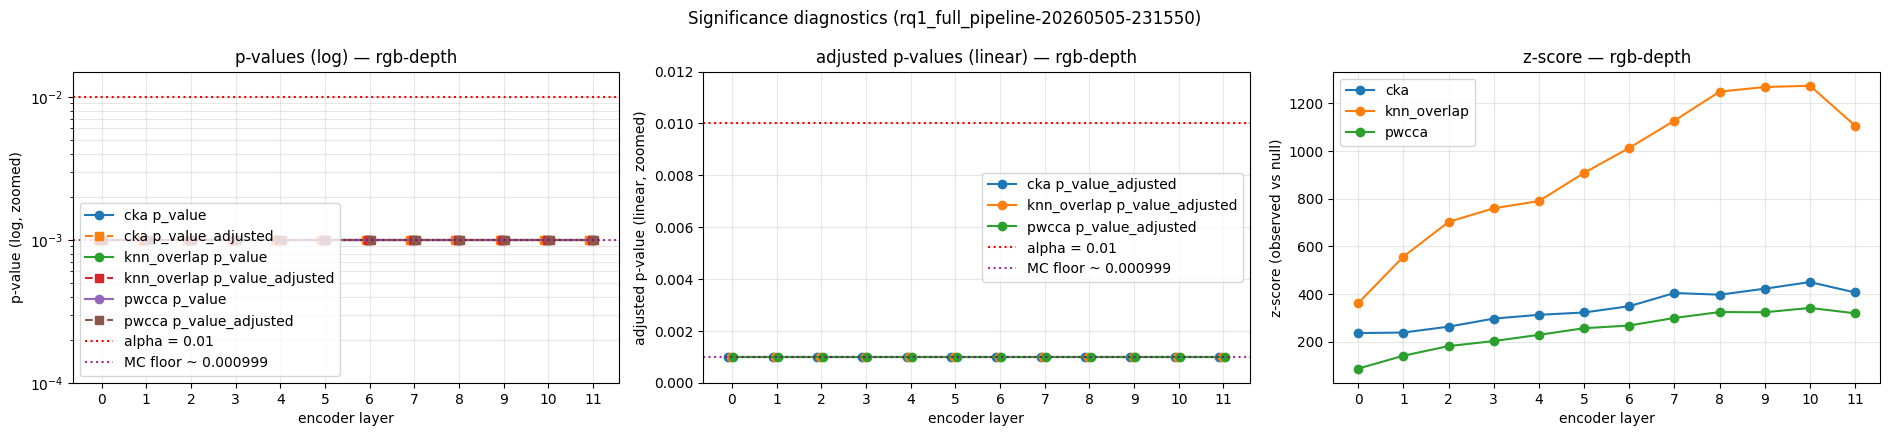

In [23]:
# p-value (log), adjusted p-value (linear), and z-score vs layer.
sig_df = metrics.dropna(subset=["p_value"]).copy()

if sig_df.empty:
    print("No p-values found in metrics.csv — null distribution may not be computed for any metric.")
else:
    sig_metrics = sorted(sig_df["metric"].unique())
    sig_pairs = sorted(sig_df["pair"].unique())
    eps = 1e-12

    draw_counts = (
        null_df.groupby(["pair", "metric", "layer"]).size().rename("n_draws").reset_index()
        if not null_df.empty
        else pd.DataFrame(columns=["pair", "metric", "layer", "n_draws"])
    )

    for pair in sig_pairs:
        pair_df = sig_df[sig_df["pair"] == pair]
        if pair_df.empty:
            continue

        pair_draws = draw_counts[draw_counts["pair"] == pair]
        min_draws = int(pair_draws["n_draws"].min()) if not pair_draws.empty else 0
        p_floor = 1.0 / (min_draws + 1) if min_draws > 0 else np.nan

        fig, axes = plt.subplots(1, 3, figsize=(19, 4.4))

        # 1) Raw/adjusted p-values on log scale
        ax = axes[0]
        for i, m in enumerate(sig_metrics):
            sub = pair_df[pair_df["metric"] == m].sort_values("layer_idx")
            if sub.empty:
                continue
            x = sub["layer_idx"].to_numpy(dtype=float) + (i - len(sig_metrics) / 2) * 0.06
            ax.plot(x, sub["p_value"], marker="o", label=f"{m} p_value")
            if "p_value_adjusted" in sub.columns and sub["p_value_adjusted"].notna().any():
                ax.plot(
                    x,
                    sub["p_value_adjusted"],
                    marker="s",
                    linestyle="--",
                    label=f"{m} p_value_adjusted",
                )
        ax.axhline(ALPHA, linestyle=":", color="red", label=f"alpha = {ALPHA}")
        ax.set_yscale("log")
        # Zoom near tiny p-values to avoid a flat-looking line at the bottom.
        ax.set_ylim(1e-4, max(ALPHA * 1.5, 2e-3))
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("p-value (log, zoomed)")
        if np.isfinite(p_floor):
            ax.axhline(p_floor, linestyle=":", color="purple", alpha=0.8, label=f"MC floor ~ {p_floor:.3g}")
        ax.set_xticks(sorted(pair_df["layer_idx"].unique()))
        ax.set_title(f"p-values (log) — {pair}")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3, which="both")

        # 2) Adjusted p-values on linear scale
        ax = axes[1]
        has_adjusted = False
        max_adj = 0.0
        for i, m in enumerate(sig_metrics):
            sub = pair_df[pair_df["metric"] == m].sort_values("layer_idx")
            if sub.empty or "p_value_adjusted" not in sub.columns or not sub["p_value_adjusted"].notna().any():
                continue
            has_adjusted = True
            y = sub["p_value_adjusted"].to_numpy(dtype=float)
            x = sub["layer_idx"].to_numpy(dtype=float) + (i - len(sig_metrics) / 2) * 0.06
            ax.plot(x, y, marker="o", label=f"{m} p_value_adjusted")
            max_adj = max(max_adj, float(np.nanmax(y)))
        ax.axhline(ALPHA, linestyle=":", color="red", label=f"alpha = {ALPHA}")
        if np.isfinite(p_floor):
            ax.axhline(p_floor, linestyle=":", color="purple", alpha=0.8, label=f"MC floor ~ {p_floor:.3g}")
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("adjusted p-value (linear, zoomed)")
        ax.set_xticks(sorted(pair_df["layer_idx"].unique()))
        ax.set_ylim(0.0, max(ALPHA * 1.2, max_adj * 1.3 if max_adj > 0 else 0.02, (p_floor * 8) if np.isfinite(p_floor) else 0.0))
        ax.set_title(f"adjusted p-values (linear) — {pair}")
        if has_adjusted:
            ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

        # 3) z-score
        ax = axes[2]
        has_z = False
        for m in sig_metrics:
            sub = pair_df[pair_df["metric"] == m].sort_values("layer_idx")
            if sub.empty or "z_score" not in sub.columns or not sub["z_score"].notna().any():
                continue
            has_z = True
            ax.plot(sub["layer_idx"], sub["z_score"], marker="o", label=m)
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("z-score (observed vs null)")
        ax.set_xticks(sorted(pair_df["layer_idx"].unique()))
        ax.set_title(f"z-score — {pair}")
        if has_z:
            ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

        fig.suptitle(f"Significance diagnostics ({RUN_ID})")
        fig.tight_layout()
        plt.show()

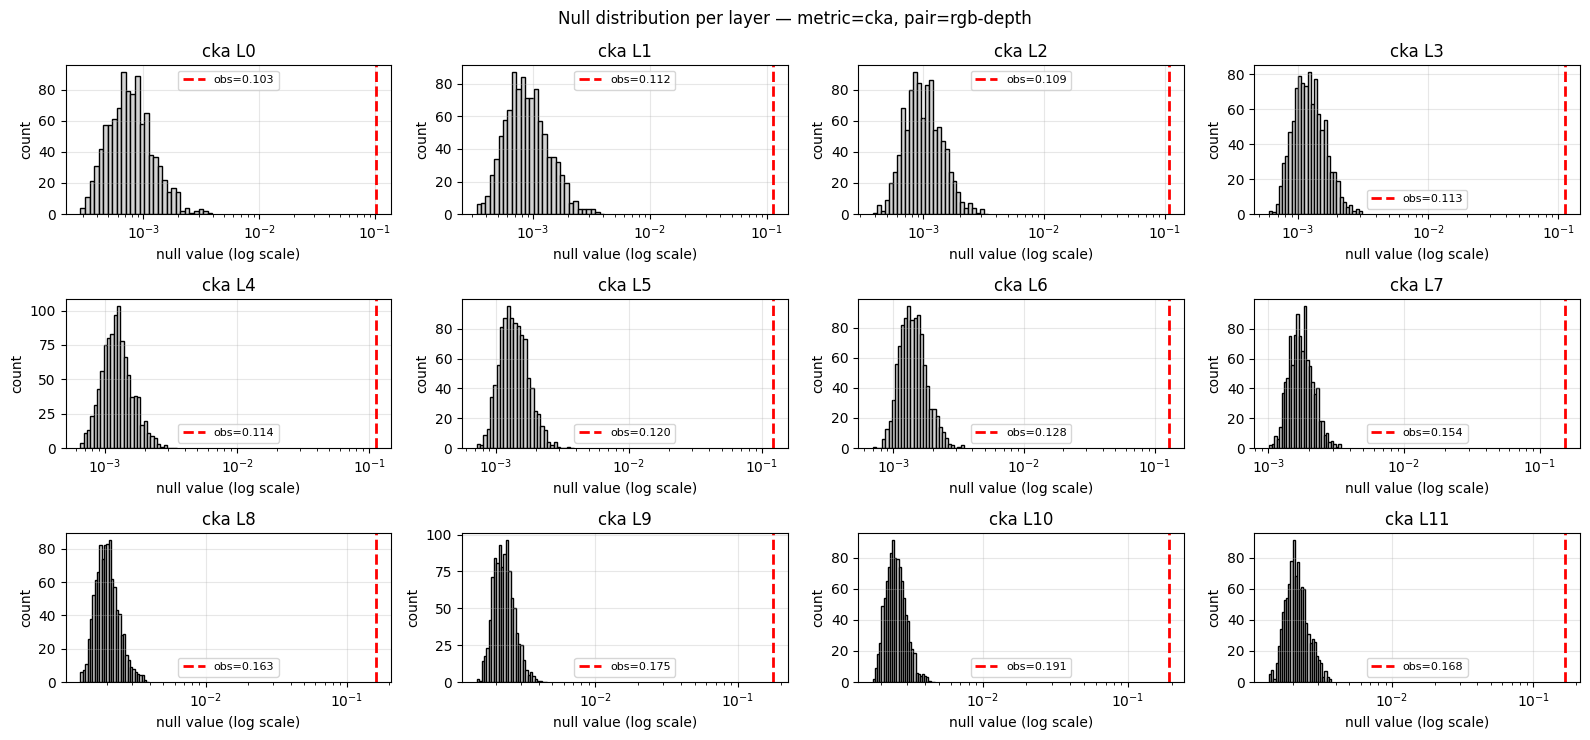

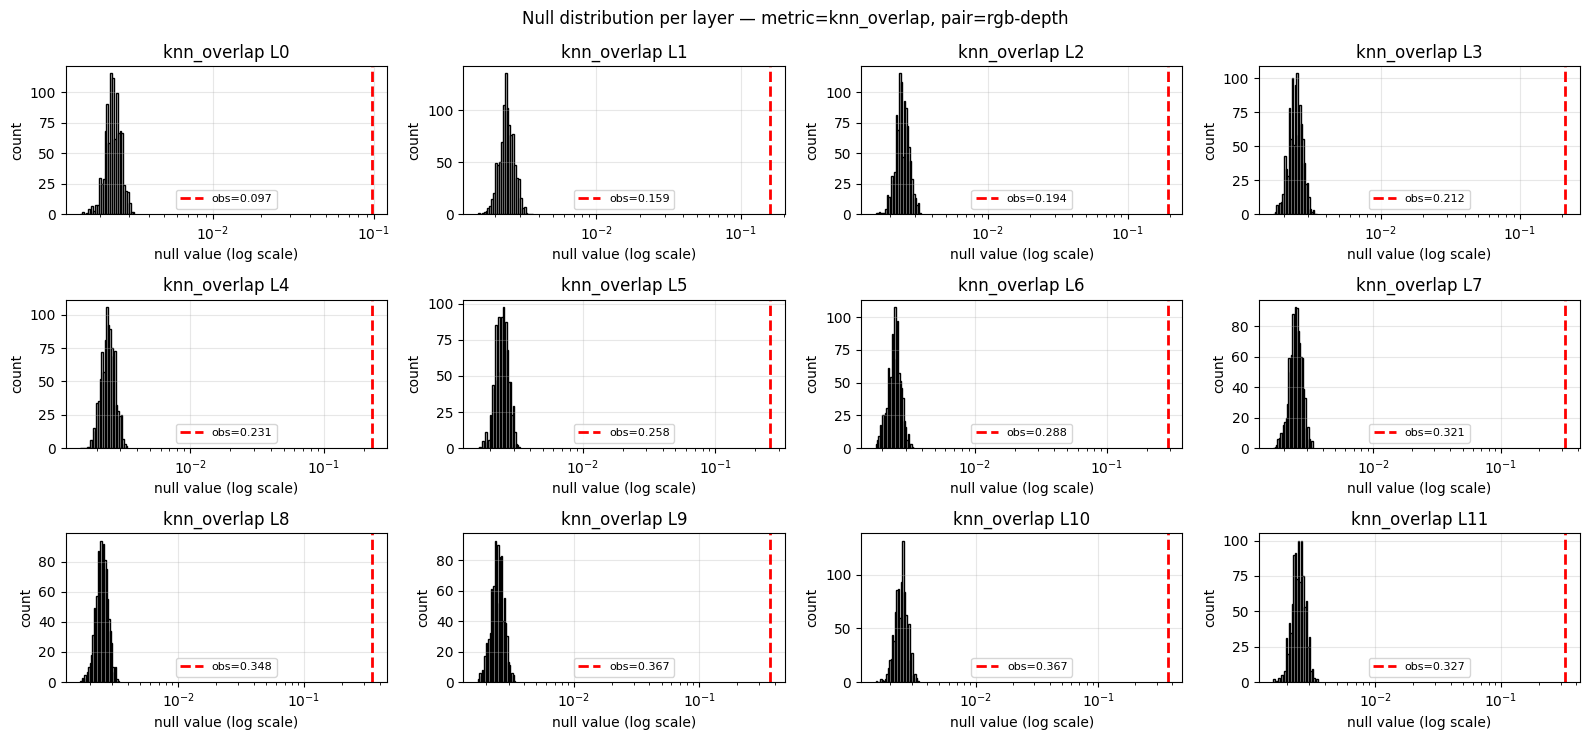

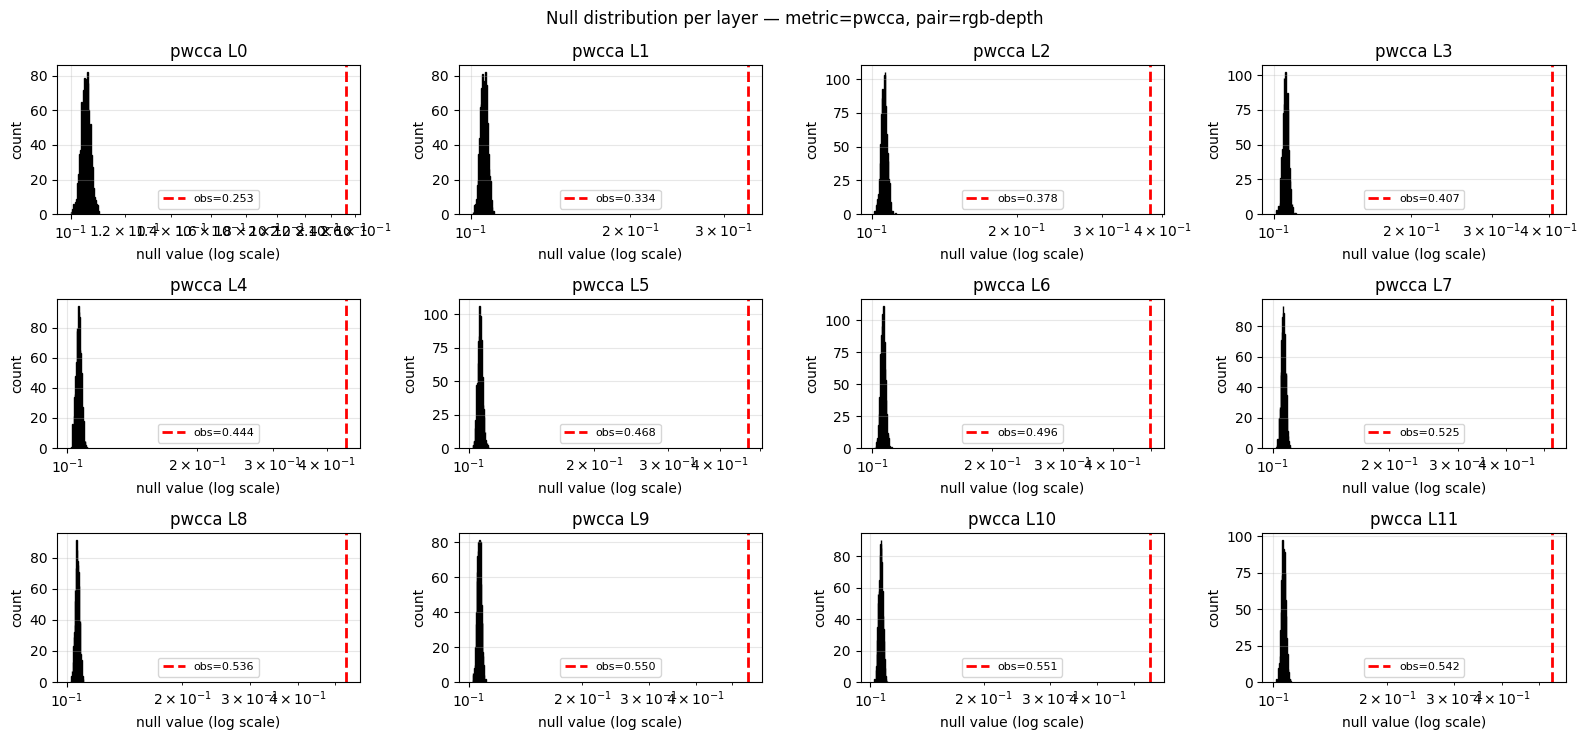

In [16]:
# Per-layer null distribution histograms with the observed value marked.
for pair in sorted(null_df["pair"].unique()):
    for m in sorted(null_df.loc[null_df["pair"] == pair, "metric"].unique()):
        null_sub = null_df[(null_df["metric"] == m) & (null_df["pair"] == pair)]
        obs_sub = metrics[(metrics["metric"] == m) & (metrics["pair"] == pair)]
        layers = sorted(null_sub["layer_idx"].unique())
        n = len(layers)
        cols = 4
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.5 * rows))
        axes = np.atleast_2d(axes)

        for idx, lid in enumerate(layers):
            ax = axes[idx // cols, idx % cols]
            null_vals = null_sub.loc[null_sub["layer_idx"] == lid, "null_value"].to_numpy(dtype=float)
            pos_vals = null_vals[null_vals > 0]
            if len(pos_vals) > 0 and float(pos_vals.max()) > float(pos_vals.min()):
                bins = np.logspace(np.log10(pos_vals.min()), np.log10(pos_vals.max()), 30)
                ax.hist(pos_vals, bins=bins, color="lightgrey", edgecolor="black")
                ax.set_xscale("log")
            else:
                ax.hist(null_vals, bins=30, color="lightgrey", edgecolor="black")

            obs_row = obs_sub[obs_sub["layer_idx"] == lid]
            if not obs_row.empty:
                obs_val = float(obs_row["value"].iloc[0])
                if obs_val > 0:
                    ax.axvline(obs_val, color="red", linestyle="--", linewidth=2, label=f"obs={obs_val:.3f}")
                    ax.legend(loc="best", fontsize=8)
            ax.set_title(f"{m} L{lid}")
            ax.set_xlabel("null value (log scale)")
            ax.set_ylabel("count")
            ax.grid(True, alpha=0.3)

        for idx in range(n, rows * cols):
            axes[idx // cols, idx % cols].axis("off")

        fig.suptitle(f"Null distribution per layer — metric={m}, pair={pair}")
        fig.tight_layout()
        plt.show()

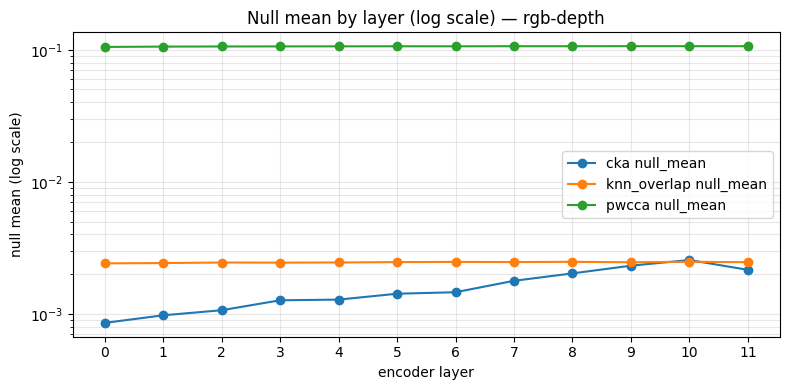

Tip: if values are very close, compare with null_std or use log10(null_mean) explicitly.


In [5]:
# Null mean on log scale (requested): helps inspect tiny but non-zero null baselines.
null_stats = (
    null_df.groupby(["pair", "metric", "layer", "layer_idx"]) ["null_value"]
    .agg(null_mean="mean", null_std="std")
    .reset_index()
    .sort_values(["pair", "metric", "layer_idx"])
)

for pair in sorted(null_stats["pair"].unique()):
    pair_stats = null_stats[null_stats["pair"] == pair]
    fig, ax = plt.subplots(figsize=(8, 4))
    for m in sorted(pair_stats["metric"].unique()):
        sub = pair_stats[pair_stats["metric"] == m].sort_values("layer_idx")
        if sub.empty:
            continue
        ax.plot(sub["layer_idx"], sub["null_mean"], marker="o", label=f"{m} null_mean")

    ax.set_yscale("log")
    ax.set_xlabel("encoder layer")
    ax.set_ylabel("null mean (log scale)")
    ax.set_xticks(sorted(pair_stats["layer_idx"].unique()))
    ax.set_title(f"Null mean by layer (log scale) — {pair}")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("Tip: if values are very close, compare with null_std or use log10(null_mean) explicitly.")

In [6]:
# Optional diagnostics: scene-type enrichment in the high-null tail.
# Helps detect scene types that dominate large null values, which would
# bias the null distribution.
TAILS = [0.95, 0.99]


def side_enrichment(df_all: pd.DataFrame, df_tail: pd.DataFrame) -> pd.DataFrame:
    all_side = pd.concat([
        df_all[["left_scene_type"]].rename(columns={"left_scene_type": "scene_type"}),
        df_all[["right_scene_type"]].rename(columns={"right_scene_type": "scene_type"}),
    ], ignore_index=True)
    tail_side = pd.concat([
        df_tail[["left_scene_type"]].rename(columns={"left_scene_type": "scene_type"}),
        df_tail[["right_scene_type"]].rename(columns={"right_scene_type": "scene_type"}),
    ], ignore_index=True)

    all_counts = all_side["scene_type"].value_counts().rename("all_count")
    tail_counts = tail_side["scene_type"].value_counts().rename("tail_count")

    out = pd.concat([all_counts, tail_counts], axis=1).fillna(0)
    out["all_count"] = out["all_count"].astype(int)
    out["tail_count"] = out["tail_count"].astype(int)
    out["all_rate"] = out["all_count"] / max(out["all_count"].sum(), 1)
    out["tail_rate"] = out["tail_count"] / max(out["tail_count"].sum(), 1)
    out["lift"] = out["tail_rate"] / out["all_rate"].replace(0, np.nan)
    return (
        out.reset_index()
        .rename(columns={"index": "scene_type"})
        .sort_values("lift", ascending=False)
    )


out_root = project_root / "results" / "runs" / RUN_ID / "diagnostics"
out_root.mkdir(parents=True, exist_ok=True)

for metric_name in sorted(null_df["metric"].unique()):
    print(f"\n=== Metric: {metric_name} ===")
    dnull = null_df[null_df["metric"] == metric_name].copy()
    for q in TAILS:
        thr = float(dnull["null_value"].quantile(q))
        tail = dnull[dnull["null_value"] >= thr]
        print(f"\nTop {int((1 - q) * 100)}% tail (q={q}, threshold={thr:.4f}, n={len(tail)}):")
        enr = side_enrichment(dnull, tail)
        display(enr.head(10))
        enr.to_csv(out_root / f"{metric_name}_scene_type_enrichment_q{int(q*100)}.csv", index=False)
        tail.to_csv(out_root / f"{metric_name}_null_q{int(q*100)}_tail.csv", index=False)

print(f"\nDiagnostic CSVs saved under: {out_root}")


=== Metric: cka ===

Top 5% tail (q=0.95, threshold=0.0028, n=600):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
15,Courtyard,566,39,0.023583,0.032500,1.378092
17,Living room,552,35,0.023000,0.029167,1.268116
14,Office (conference room),569,35,0.023708,0.029167,1.230228
18,Bathroom,535,32,0.022292,0.026667,1.196262
1,Hotel lobby,2664,154,0.111000,0.128333,1.156156
7,Hallway,1172,66,0.048833,0.055000,1.126280
5,Restaurant,1671,94,0.069625,0.078333,1.125075
6,Bedroom,1641,91,0.068375,0.075833,1.109080
12,Retail space,587,31,0.024458,0.025833,1.056218
8,Hall,1128,55,0.047000,0.045833,0.975177



Top 1% tail (q=0.99, threshold=0.0033, n=120):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
9,Office (waiting area),689,11,0.028708,0.045833,1.596517
8,Hall,1128,16,0.047000,0.066667,1.418440
5,Restaurant,1671,21,0.069625,0.087500,1.256732
1,Hotel lobby,2664,33,0.111000,0.137500,1.238739
15,Courtyard,566,7,0.023583,0.029167,1.236749
4,Office (home),2061,24,0.085875,0.100000,1.164483
7,Hallway,1172,12,0.048833,0.050000,1.023891
12,Retail space,587,6,0.024458,0.025000,1.022147
2,Kitchen,2269,21,0.094542,0.087500,0.925518
6,Bedroom,1641,15,0.068375,0.062500,0.914077



=== Metric: knn_overlap ===

Top 5% tail (q=0.95, threshold=0.0029, n=625):


...


=== Metric: pwcca ===

Top 5% tail (q=0.95, threshold=0.1085, n=600):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
17,Retail space,527,35,0.021958,0.029167,1.328273
15,Art gallery,543,35,0.022625,0.029167,1.289134
1,Hotel lobby,2773,157,0.115542,0.130833,1.132348
5,Bedroom,1724,97,0.071833,0.080833,1.125290
16,Bathroom,539,30,0.022458,0.025000,1.113173
8,Hallway,1105,60,0.046042,0.050000,1.085973
4,Office (home),2097,107,0.087375,0.089167,1.020505
14,Courtyard,556,28,0.023167,0.023333,1.007194
9,Office (waiting area),698,35,0.029083,0.029167,1.002865
11,Other,586,29,0.024417,0.024167,0.989761



Top 1% tail (q=0.99, threshold=0.1095, n=120):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
7,Hall,1142,20,0.047583,0.083333,1.751313
5,Bedroom,1724,27,0.071833,0.112500,1.566125
15,Art gallery,543,8,0.022625,0.033333,1.473297
17,Retail space,527,7,0.021958,0.029167,1.328273
11,Other,586,7,0.024417,0.029167,1.194539
8,Hallway,1105,13,0.046042,0.054167,1.176471
18,Living room,524,6,0.021833,0.025000,1.145038
2,Kitchen,2256,24,0.094000,0.100000,1.063830
6,Restaurant,1656,17,0.069000,0.070833,1.026570
10,Dining room,591,6,0.024625,0.025000,1.015228



Diagnostic CSVs saved under: C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\diagnostics\rq1_full_pipeline-20260505-231550


In [7]:
# Common derived quantities used by the interpretation plots.
EPS = 1e-12

viz_df = metrics.copy()
if "null_mean" not in viz_df.columns:
    viz_df["null_mean"] = np.nan
if "null_std" not in viz_df.columns:
    viz_df["null_std"] = np.nan
if "p_value_adjusted" not in viz_df.columns:
    viz_df["p_value_adjusted"] = np.nan
if "z_score" not in viz_df.columns:
    viz_df["z_score"] = np.nan

viz_df["fold_change"] = viz_df["value"] / (viz_df["null_mean"].abs() + EPS)
viz_df["log10_fold_change"] = np.log10(np.maximum(viz_df["fold_change"], EPS))
viz_df["delta_vs_null"] = viz_df["value"] - viz_df["null_mean"]
viz_df["neglog10_p_adj"] = -np.log10(np.maximum(viz_df["p_value_adjusted"], EPS))

display(viz_df[["pair", "metric", "layer", "value", "null_mean", "null_std", "delta_vs_null", "z_score", "p_value_adjusted", "log10_fold_change"]].head())

,pair,metric,layer,value,null_mean,null_std,delta_vs_null,z_score,p_value_adjusted,log10_fold_change
0,rgb-depth,cka,layer_00,0.102986,0.000853,0.000434,0.102133,235.526663,0.000999,2.081640
1,rgb-depth,cka,layer_01,0.111719,0.000974,0.000466,0.110745,237.816914,0.000999,2.059550
2,rgb-depth,cka,layer_02,0.108806,0.001064,0.000410,0.107741,262.484620,0.000999,2.009542
3,rgb-depth,cka,layer_03,0.113055,0.001266,0.000377,0.111789,296.405949,0.000999,1.950997
4,rgb-depth,cka,layer_04,0.113502,0.001281,0.000360,0.112222,312.135903,0.000999,1.947534


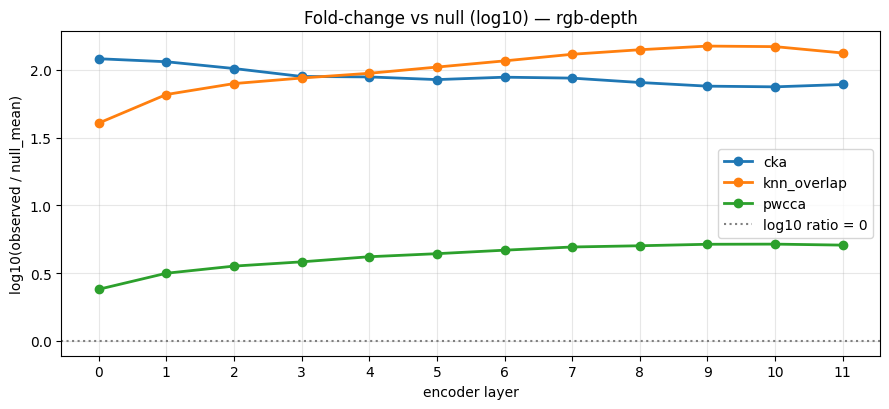

In [8]:
# 1) log10(observed / null_mean) vs layer.
for pair in sorted(viz_df["pair"].unique()):
    sub_pair = viz_df[viz_df["pair"] == pair]
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for m in sorted(sub_pair["metric"].unique()):
        sub = sub_pair[sub_pair["metric"] == m].sort_values("layer_idx")
        if sub["null_mean"].notna().sum() == 0:
            continue
        ax.plot(sub["layer_idx"], sub["log10_fold_change"], marker="o", linewidth=2, label=m)

    ax.axhline(0.0, linestyle=":", color="grey", label="log10 ratio = 0")
    ax.set_xlabel("encoder layer")
    ax.set_ylabel("log10(observed / null_mean)")
    ax.set_xticks(sorted(sub_pair["layer_idx"].unique()))
    ax.set_title(f"Fold-change vs null (log10) — {pair}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

C:\Users\arthu\AppData\Local\Temp\ipykernel_8668\722190030.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


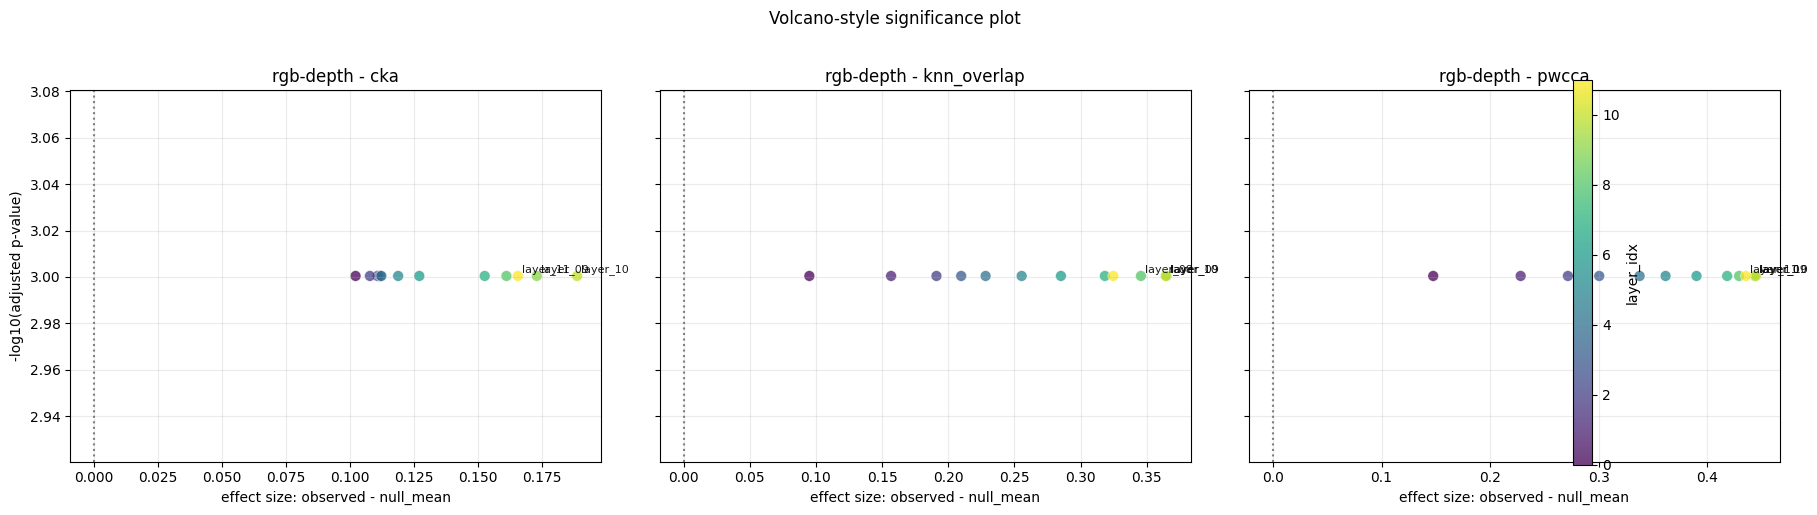

In [17]:
# 2) Volcano-like plot: effect size (delta) vs -log10(adjusted p-value).
# No y-jitter here: vertical spread now reflects real p-value differences.
for pair in sorted(viz_df["pair"].unique()):
    sub_pair = viz_df[viz_df["pair"] == pair].copy()
    sub_pair = sub_pair.dropna(subset=["delta_vs_null", "p_value_adjusted"])
    if sub_pair.empty:
        continue

    metrics = sorted(sub_pair["metric"].unique())
    n_cols = len(metrics)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=True)
    if n_cols == 1:
        axes = [axes]

    y_alpha = -np.log10(ALPHA)
    all_y = sub_pair["neglog10_p_adj"].to_numpy(dtype=float)
    y_lo = float(np.nanmin(all_y)) if len(all_y) else 0.0
    y_hi = float(np.nanmax(all_y)) if len(all_y) else 1.0
    if (y_hi - y_lo) < 0.12:
        pad = 0.08
        y_lo = max(0.0, y_lo - pad)
        y_hi = y_hi + pad

    for ax, m in zip(axes, metrics):
        sub = sub_pair[sub_pair["metric"] == m].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        sc = ax.scatter(
            sub["delta_vs_null"],
            sub["neglog10_p_adj"],
            s=60,
            alpha=0.75,
            edgecolors="white",
            linewidth=0.4,
            c=sub["layer_idx"],
            cmap="viridis",
        )

        label_candidates = sub.assign(_abs_delta=sub["delta_vs_null"].abs())
        to_label = label_candidates.nlargest(3, "_abs_delta")
        for _, row in to_label.iterrows():
            ax.annotate(
                str(row["layer"]),
                (row["delta_vs_null"], row["neglog10_p_adj"]),
                fontsize=8,
                alpha=0.9,
                xytext=(3, 3),
                textcoords="offset points",
            )

        ax.axvline(0.0, linestyle=":", color="grey")
        ax.axhline(y_alpha, linestyle=":", color="red", label=f"alpha={ALPHA}")
        ax.set_ylim(y_lo, y_hi)
        ax.set_title(f"{pair} - {m}")
        ax.set_xlabel("effect size: observed - null_mean")
        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel("-log10(adjusted p-value)")
    cbar = fig.colorbar(sc, ax=axes, fraction=0.03, pad=0.02)
    cbar.set_label("layer_idx")
    fig.suptitle("Volcano-style significance plot", y=1.02)
    plt.tight_layout()
    plt.show()

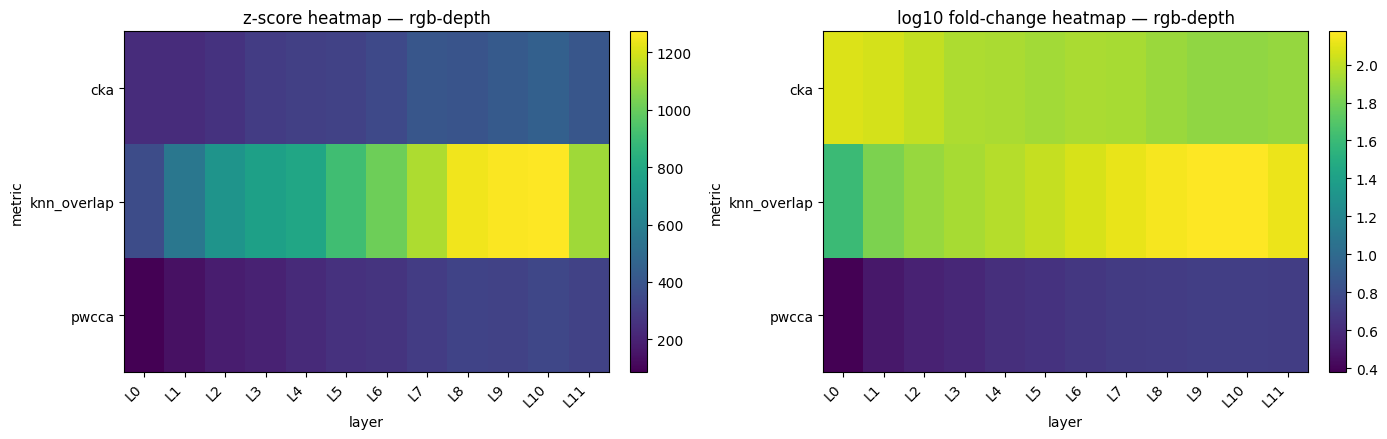

In [10]:
# 3) Heatmaps: z_score and fold-change (log10) for metric x layer.
for pair in sorted(viz_df["pair"].unique()):
    sub_pair = viz_df[viz_df["pair"] == pair].copy()
    if sub_pair.empty:
        continue

    z_mat = (
        sub_pair.pivot_table(index="metric", columns="layer_idx", values="z_score", aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )
    fc_mat = (
        sub_pair.pivot_table(index="metric", columns="layer_idx", values="log10_fold_change", aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    im0 = axes[0].imshow(z_mat.values, aspect="auto", interpolation="nearest")
    axes[0].set_title(f"z-score heatmap — {pair}")
    axes[0].set_xlabel("layer")
    axes[0].set_ylabel("metric")
    axes[0].set_xticks(range(len(z_mat.columns)))
    axes[0].set_xticklabels([f"L{int(c)}" for c in z_mat.columns], rotation=45, ha="right")
    axes[0].set_yticks(range(len(z_mat.index)))
    axes[0].set_yticklabels(z_mat.index.tolist())
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(fc_mat.values, aspect="auto", interpolation="nearest")
    axes[1].set_title(f"log10 fold-change heatmap — {pair}")
    axes[1].set_xlabel("layer")
    axes[1].set_ylabel("metric")
    axes[1].set_xticks(range(len(fc_mat.columns)))
    axes[1].set_xticklabels([f"L{int(c)}" for c in fc_mat.columns], rotation=45, ha="right")
    axes[1].set_yticks(range(len(fc_mat.index)))
    axes[1].set_yticklabels(fc_mat.index.tolist())
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [11]:
# 4) Small report-ready table + CSV export.
report_cols = [
    "pair",
    "metric",
    "layer",
    "n_samples",
    "value",
    "null_mean",
    "null_std",
    "delta_vs_null",
    "z_score",
    "p_value",
    "p_value_adjusted",
    "is_significant",
    "log10_fold_change",
]

report_ready = (
    viz_df.sort_values(["pair", "metric", "layer_idx"])
    .loc[:, report_cols]
    .reset_index(drop=True)
)

out_root = project_root / "results" / "runs" / RUN_ID / "diagnostics"
out_root.mkdir(parents=True, exist_ok=True)
out_csv = out_root / "report_ready_significance_table.csv"
report_ready.to_csv(out_csv, index=False)

print(f"Saved report-ready table: {out_csv}")
display(report_ready)

Saved report-ready table: C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\diagnostics\rq1_full_pipeline-20260505-231550\report_ready_significance_table.csv


,pair,metric,layer,n_samples,value,null_mean,null_std,delta_vs_null,z_score,p_value,p_value_adjusted,is_significant,log10_fold_change
0,rgb-depth,cka,layer_00,4325,0.102986,0.000853,0.000434,0.102133,235.526663,0.000999,0.000999,True,2.081640
1,rgb-depth,cka,layer_01,4325,0.111719,0.000974,0.000466,0.110745,237.816914,0.000999,0.000999,True,2.059550
2,rgb-depth,cka,layer_02,4325,0.108806,0.001064,0.000410,0.107741,262.484620,0.000999,0.000999,True,2.009542
3,rgb-depth,cka,layer_03,4325,0.113055,0.001266,0.000377,0.111789,296.405949,0.000999,0.000999,True,1.950997
4,rgb-depth,cka,layer_04,4325,0.113502,0.001281,0.000360,0.112222,312.135903,0.000999,0.000999,True,1.947534
5,rgb-depth,cka,layer_05,4325,0.120186,0.001419,0.000369,0.118767,322.013653,0.000999,0.000999,True,1.927830
6,rgb-depth,cka,layer_06,4325,0.128497,0.001457,0.000365,0.127040,348.316041,0.000999,0.000999,True,1.945516
7,rgb-depth,cka,layer_07,4325,0.154387,0.001778,0.000378,0.152609,403.728517,0.000999,0.000999,True,1.938709
8,rgb-depth,cka,layer_08,4325,0.163118,0.002023,0.000406,0.161094,396.572220,0.000999,0.000999,True,1.906414
9,rgb-depth,cka,layer_09,4325,0.175281,0.002314,0.000410,0.172967,421.830778,0.000999,0.000999,True,1.879426
